<a href="https://colab.research.google.com/github/LigthSan/SparkImf/blob/main/EXAMEN_FINAL_M6_BIG_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DESCARGANDO LOS DATASET CON COMANDOS LINUX
!pip install pyspark

# IMPORTANDO LAS LIBRERIAS
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, FloatType

# CREANDO LA SESIÓN DE SPARK
spark = SparkSession.builder.appName("PracticaFinalBigData").getOrCreate()

!wget -O /tmp/netflix_titles_dirty_01.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_01.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_02.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_02.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_03.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_03.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_04.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_04.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_05.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_05.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_06.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_06.csv.gz?raw=True'
!wget -O /tmp/netflix_titles_dirty_07.csv.gz 'https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_07.csv.gz?raw=True'


--2026-03-22 03:51:06--  https://github.com/datacamp/data-cleaning-with-pyspark-live-training/blob/master/data/netflix_titles_dirty_01.csv.gz?raw=True
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/datacamp/data-cleaning-with-pyspark-live-training/raw/refs/heads/master/data/netflix_titles_dirty_01.csv.gz [following]
--2026-03-22 03:51:07--  https://github.com/datacamp/data-cleaning-with-pyspark-live-training/raw/refs/heads/master/data/netflix_titles_dirty_01.csv.gz
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/datacamp/data-cleaning-with-pyspark-live-training/refs/heads/master/data/netflix_titles_dirty_01.csv.gz [following]
--2026-03-22 03:51:07--  https://raw.githubusercontent.com/datacamp/data-cleaning-with-pyspark-live-training/refs/heads/m

In [ ]:
# VERIFICANDO SI SE HA DESCARGADO LOS ARCHIVOS DEL DATASET CORRECTAMENTE
!ls /tmp/netflix_titles*

/tmp/netflix_titles_dirty_01.csv.gz  /tmp/netflix_titles_dirty_05.csv.gz
/tmp/netflix_titles_dirty_02.csv.gz  /tmp/netflix_titles_dirty_06.csv.gz
/tmp/netflix_titles_dirty_03.csv.gz  /tmp/netflix_titles_dirty_07.csv.gz
/tmp/netflix_titles_dirty_04.csv.gz


SE TIENE COMO COMPROBADO QUE ESTAN LOS ARCHIVOS DESCARGADOS EN LA CARPETA TEMPORAL 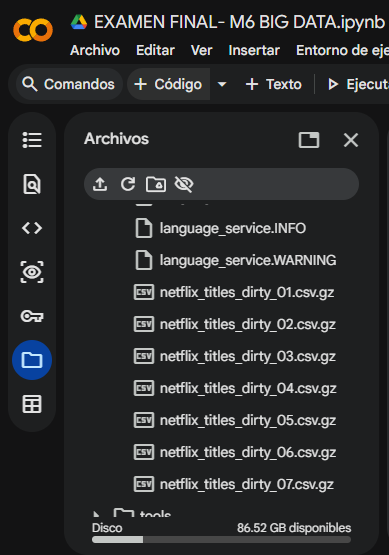

In [ ]:
# DESCOMPRIMIENDO LOS ARCHIVOS ALMACENADOS DE LA CARPETA TMP
!gunzip -c /tmp/netflix_titles_dirty_03.csv.gz | head -20

80142103	Movie	Bottom of the World	Richard Sears	Jena Malone, Douglas Smith, Ted Levine, Tamara Duarte, Kelly Pendygraft, Mark Sivertsen, Jon McLaren	Canada, United States	March 31, 2017	2017	TV-MA	84 min	Dramas, Independent Movies, Thrillers	En route to a fresh start in Los Angeles, young couple Alex and Scarlett stop over in a sleepy Southwestern town that loosens their grip on reality.
80179907	Movie	Bridget Christie: Stand Up for Her		Bridget Christie	United Kingdom	March 31, 2017	2016	TV-MA	51 min	Stand-Up Comedy	Performing stand-up for a packed house in London's Hoxton Hall, comedian Bridget Christie dives into the politics of gender, sex and equality.
80152842	Movie	FirstBorn	Nirpal Bhogal	Antonia Thomas, Luke Norris, Thea Petrie, Eileen Davies, Jonathan Hyde	United Kingdom	March 31, 2017	2016	TV-MA	90 min	Horror Movies, International Movies	A young couple fights supernatural foes in an attempt to save their daughter from the dark and mysterious forces that follow her every move

In [ ]:
# INCISO 1.
# LEYENDO TODOS LOS ARCHIVOS DESCARGADOS Y DESCOMPRIMIDOS USANDO EL ASTERISCO PARA LEER TODOS LOS ARCHIVOS DE NETFLIX

# AQUI TENEMOS UN PROBLEMA AL EJECUTAR EL HEADER CON VALOR TRUE, EL PYSPARK LO ESTA TOMANDO
# df = spark.read.csv("/tmp/netflix_titles_dirty_*.csv.gz", header=True, inferSchema=True, sep="\t", quote='"', escape='"', multiLine=True)

# INCISO 1
# LEYENDO CON EL HEADER EN FALSE
df = spark.read.csv("/tmp/netflix_titles_dirty_*.csv.gz", header=False, inferSchema=True, sep="\t", quote='"', escape='"', multiLine=True)


# AQUI TENEMOS UN PROBLEMA AL EJECUTAR EL HEADER CON VALOR TRUE, EL PYSPARK LO ESTA TOMANDO LA CABECERA COMO PRIMERA FILA LO QUE HACE QUE CONTENGA ERRORES DE FORMATO O DATOS DESPLAZADOS, POR LO TANTO, AL COLOCAR EL HEADER COMO FALSE, SE ALINEA CORRECTAMENTE PARA QUE POSTERIORMENTE SE PUEDA ELIMINAR LOS DATOS NULOS COMO EN EL INCISO 3
df = spark.read.csv("/tmp/netflix_titles_dirty_*.csv.gz", header=True, inferSchema=True, sep="\t", quote='"', escape='"', multiLine=True)

# INCISO 1
# LEYENDO CON EL HEADER EN FALSE
#df_raw = spark.read.csv("/tmp/netflix_titles_dirty_*.csv.gz", header=False, sep="\t", inferSchema=True, quote='"', multiLine=True)

In [ ]:
# INCISO 2.
# RENOMBRANDO LAS COLUMNAS DE ESTA MANERA PARA QUE AL EJECUTAR CON EL PRINTSCHEMA
# SE MUESTRE EL TITULO DE LOS ENCABEZADOS CON SUS RESPECTIVOS NOMBRES EN LA VARIABLE COLUMNAS Y ESTA SE AGREGUE AL DF
# SIN TENER QUE UTILIZAR EL withColumnRenamed
columnas = ["IdProduction", "Type", "Title", "Director", "Distribution", "Country",
            "DateAdd", "YearRelease", "Classification", "Duration", "Gender", "Description"]

df = df.toDF(*columnas)

# IMPRIMIENDO LOS NOMBRES DE LAS COLUMNAS
df.printSchema()

root
 |-- IdProduction: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Director: string (nullable = true)
 |-- Distribution: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- DateAdd: string (nullable = true)
 |-- YearRelease: string (nullable = true)
 |-- Classification: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Description: string (nullable = true)



In [ ]:
# MOSTRANDO LOS 20 PRIMEROS REGISTROS PARA HACER LA PRUEBA
df.show()
#df.summary().show()

+------------+-------+--------------------+--------------------+--------------------+--------------------+---------------+-----------+--------------+--------+--------------------+--------------------+
|IdProduction|   Type|               Title|            Director|        Distribution|             Country|        DateAdd|YearRelease|Classification|Duration|              Gender|         Description|
+------------+-------+--------------------+--------------------+--------------------+--------------------+---------------+-----------+--------------+--------+--------------------+--------------------+
|    81002212|  Movie|            Bioscope|Gajendra Ahire, V...|Nina Kulkarni, Su...|               India|August 15, 2018|       2015|         TV-14| 131 min|Dramas, Internati...|Inspired by class...|
|    80176707|  Movie|  For Here or to Go?|   Rucha Humnabadkar|Ali Fazal, Melani...|United States, India|August 15, 2018|       2015|         TV-MA| 105 min|Comedies, Dramas,...|A software engine

In [ ]:
# INCISO 3
# LIMPIANDO LAS FILAS CON VALORES NULOS
df_not_null = df.dropna()

# VAMOS A VERIFICAR SI LAS FILAS DENTRO DE TYPE (MOVIE Y TV SHOW) SON VALIDAS
valid_category_= ["Movie", "TV Show"]

# DEJANDO LIMPIO DENTRO DE LA COLUMNA TYPE DE LAS FILAS MOVIE O TV SHOW QUE ESTOS CONTENGAN VALORES NULOS
df_clean = df_not_null.filter(F.col("Type").isin(valid_category_))

# MOSTRANDO UN DF MUCHO MÁS LIMPIO SIN NULOS
df_clean.show()

+------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+-----------+--------------+--------+--------------------+--------------------+
|IdProduction| Type|               Title|            Director|        Distribution|             Country|        DateAdd|YearRelease|Classification|Duration|              Gender|         Description|
+------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+-----------+--------------+--------+--------------------+--------------------+
|    81002212|Movie|            Bioscope|Gajendra Ahire, V...|Nina Kulkarni, Su...|               India|August 15, 2018|       2015|         TV-14| 131 min|Dramas, Internati...|Inspired by class...|
|    80176707|Movie|  For Here or to Go?|   Rucha Humnabadkar|Ali Fazal, Melani...|United States, India|August 15, 2018|       2015|         TV-MA| 105 min|Comedies, Dramas,...|A software engine...|
|    

In [ ]:
df_clean.summary()

DataFrame[summary: string, IdProduction: string, Type: string, Title: string, Director: string, Distribution: string, Country: string, DateAdd: string, YearRelease: string, Classification: string, Duration: string, Gender: string, Description: string]

In [ ]:
# INCISO 4
# VAMOS A AÑADIR LOS TIPOS DE DATOS INTEGER Y DATE TYPE YA QUE ARRIBA SOLO TENIAMOS STRING Y FLOAT
from pyspark.sql.types import IntegerType, DateType

# VAMOS A EXTRAER SOLO EL NÚMERO DE LA COLUMNA DURATION DEL DF_CLEAN EN NUESTRA VARIABLE DF_FINAL
df_final = df_clean.withColumn("Duration", F.regexp_extract(F.col("Duration"), r"(\d+)", 1).cast(IntegerType()))

# CONVIRTIENDO EL AÑO DE LANZAMIENTO EN TIPO ENTERO, QUE ANTES LO TENÍAMOS COMO STRING, E IMPRIMIENDO EN PRINTSCHEMA
df_final = df_final.withColumn("YearRelease", F.col("YearRelease").cast(IntegerType()))

df_final.printSchema()

root
 |-- IdProduction: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Director: string (nullable = true)
 |-- Distribution: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- DateAdd: string (nullable = true)
 |-- YearRelease: integer (nullable = true)
 |-- Classification: string (nullable = true)
 |-- Duration: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Description: string (nullable = true)



In [ ]:
# INCISO 5
# VAMOS A FILTRAR UNICAMENTE POR PELICULAS EN FUNCION DEL PAÍS
df_movie = df_final.filter(F.col("Type") == "Movie")

# AGRUPANDO POR DURACIÓN MEDIA EN FUNCIÓN DEL PAÍS Y VAMOS A RENOMBRAR CON EL NOMBRE DE MeanDuration LA VARIABLE DE DURATION
df_movie_avg_country = df_movie.groupBy("Country").mean("Duration")

# RENOMBRANDO Y ORDENANDO DE MANERA DESCENDIENTE
df_movie_avg_country = df_movie_avg_country.withColumnRenamed("avg(Duration)","MeanDurationMovie").orderBy(F.desc("MeanDurationMovie"))

# MOSTRANDO LA MEDIA DE DURACIÓN EN FUNCIÓN DEL PAÍS
df_movie_avg_country.show()

+--------------------+-----------------+
|             Country|MeanDurationMovie|
+--------------------+-----------------+
|United States, Un...|            205.0|
|United States, It...|            200.0|
|New Zealand, Unit...|            190.0|
|France, Belgium, ...|            180.0|
|Germany, United S...|            172.0|
|Italy, United States|            166.0|
|United States, Ma...|            163.0|
| India, Soviet Union|            161.5|
|United Kingdom, U...|            161.0|
|     India, Malaysia|            158.0|
|Croatia, Slovenia...|            157.0|
| Soviet Union, India|            147.0|
|    Australia, India|            145.0|
|Norway, Iceland, ...|            144.0|
|France, United St...|            143.0|
|India, United Kin...|            143.0|
|      Brazil, France|            139.0|
|China, Morocco, H...|            139.0|
|United Kingdom, I...|            139.0|
|United States, Ge...|            138.0|
+--------------------+-----------------+
only showing top

In [ ]:
# INCISO 6 - FILTRANDO LAS PELICULAS QUE CONTENGAN LA PALABRA MUSIC EN SU DESCRIPCIÓN Y MAYOR A 90 MINUTOS
df_music_global = df_final.filter((F.lower(F.col("Description")).contains("music")) & (F.col("Duration") > 90 ))

# ACTOR QUE MÁS PELICULAS Y SERIES HA REALIZADO BAJO ESTAS CONDICIONES
# AQUI VAMOS A SEPARAR LA COLUMNA DE DISTRIBUTION O REPARTO DE LAS PELICULAS USANDO EL SPLIT PARA CREAR
# UN ARRAY Y CREAR UNA FILA POR CADA ACTOR
df_actor = df_music_global.withColumn("Actor", F.explode(F.split(F.col("Distribution"), ", ")))

# AQUI ESTAMOS CONTANDO CUANTAS PELICULAS TIENE CADA ACTOR Y LO ORDENAREMOS DE FORMA ASCENDENTE EN BASE AL COUNT
top_actor_count = df_actor.groupBy("Actor").count().orderBy(F.asc("count"))

# ESTAMOS MOSTRANDO EL TOP_ACTOR_COUNT
top_actor_count.show()

+-------------------+-----+
|              Actor|count|
+-------------------+-----+
|        Jordi Mollà|    1|
|     Vincent Piazza|    1|
|       Wayne Kramer|    1|
|      John Travolta|    1|
|        Maris Racal|    1|
|    Ezzat Abou Aouf|    1|
|     Jun Lang Huang|    1|
|     Danny Bonaduce|    1|
|     Carlos Santana|    1|
|         Dana Fuchs|    1|
|  Yoakyake Chernyim|    1|
|        Vivian Bang|    1|
|        Jett Pangan|    1|
|    Agnes Moorehead|    1|
|  Denzel Washington|    1|
|     Mandy Patinkin|    1|
|Apisit Opasaimlikit|    1|
|       Mai Ezzidine|    1|
|        Jimmy Heath|    1|
|       Erich Bergen|    1|
+-------------------+-----+
only showing top 20 rows


In [ ]:
# INCISO 7
# GUARDANDO EL ACTOR, Y PARSEANDO LA COLUMNA DATEADD A TIPO DE FECHA (DATE), ESTO NOS VA PERMITIR PARA USAR EL INCISO 7
nombre_top_actor = top_actor_count.first()["Actor"]
df_actor_especifico = df_actor.withColumn("DateAdd", F.to_date(F.trim(F.col("DateAdd")),"MMMM d, yyyy"))

# VAMOS A FILTRAR PARA BUSCAR AL ACTOR TOP DESDE SU PRIMERA PRODUCCIÓN HASTA SU ÚLTIMA Y VAMOS A CALCULAR LA FECHA
df_actor_especifico = df_actor_especifico.filter(F.col("Actor") == nombre_top_actor)

# FECHA ULTIMA
date = df_actor_especifico.select(
    F.min("DateAdd").alias("First_Production"),
    F.max("DateAdd").alias("Last_Production")
    ).filter(F.col("First_Production").isNotNull())

# MOSTRANDO LA ULTIMA VEZ O CUANTAS SEMANAS PASÓ DESDE SU ÚLTIMA PRODUCCIÓN
week_result = date.withColumn("Weeks_Elapsed", F.datediff(F.col("Last_Production"), F.col("First_Production")) / 7 )

# MOSTRANDO RESULTADO
week_result.show()


+----------------+---------------+-------------+
|First_Production|Last_Production|Weeks_Elapsed|
+----------------+---------------+-------------+
|      2018-07-01|     2018-07-01|          0.0|
+----------------+---------------+-------------+



In [ ]:
# INCISO 8.
# USAMOS SPLIT PARA PODER CONVERTIR EL STRING DE "Drama, Thriller" en ["Drama", "Thriller"]
df_final = df_final.withColumn("Gender", F.split(F.col("Gender"), ", "))

# VERIFICAMOS EL ESQUEMA (AHORA DEBERÍA DE SER COMO UN ARRAY)
df_final.printSchema()
df_final.select("IdProduction", "Gender").show(5, truncate=False)

root
 |-- IdProduction: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Director: string (nullable = true)
 |-- Distribution: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- DateAdd: string (nullable = true)
 |-- YearRelease: integer (nullable = true)
 |-- Classification: string (nullable = true)
 |-- Duration: integer (nullable = true)
 |-- Gender: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- Description: string (nullable = true)

+------------+--------------------------------------------------+
|IdProduction|Gender                                            |
+------------+--------------------------------------------------+
|81002212    |[Dramas, International Movies, LGBTQ Movies]      |
|80176707    |[Comedies, Dramas, Independent Movies]            |
|80199381    |[Dramas]                                          |
|80202176    |[Comedies, Independent Movies, LGBTQ Movies] 

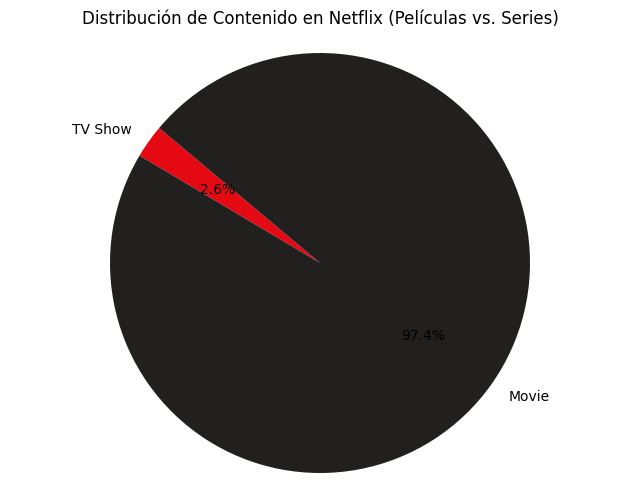

In [ ]:
# VAMOS A IMPORTAR PARA MOSTRAR CON GRÁFICA USANDO MATPLOTLIB CON PANDAS
import matplotlib.pyplot as plt

# LO PRIMERO QUE VAMOS HACER ES QUE VAMOS A CONTAR CUANTAS HAY DE CADA TIPO (MOVIE VS TV Show)
df_conteo_tipos = df_final.groupBy("Type").count().toPandas()

# AHORA VAMOS A CONFIGURAR LA GRÁFICA
plt.figure(figsize=(8, 6))
plt.pie (df_conteo_tipos['count'], labels=df_conteo_tipos['Type'], autopct='%1.1f%%', startangle=140, colors=['#E50914', '#221F1F'])

# FINALMENTE, AÑADIMOS EL TÍTULO PARA MOSTRAR
plt.title("Distribución de Contenido en Netflix (Películas vs. Series)")
plt.axis('equal')
plt.show()

In [ ]:
# INCISO 10 - EXPORTAR COMO FICHERO PARQUET
df_final.write.mode("overwrite").parquet("netflix_titles_final.parquet")

In [ ]:
# COMPRIMIENDO LA CARPETA DE NETFLIX EN ARCHIVO PARQUET
!zip -r EXAMEN_FINAL_BIG_DATA_PABLO_ARTURO_GUERRA_VIDAL.zip netflix_titles_final.parquet

updating: netflix_titles_final.parquet/ (stored 0%)
updating: netflix_titles_final.parquet/._SUCCESS.crc (stored 0%)
updating: netflix_titles_final.parquet/_SUCCESS (stored 0%)
  adding: netflix_titles_final.parquet/.part-00000-3e408bb2-9e4b-43e2-9d78-d55871309587-c000.snappy.parquet.crc (stored 0%)
  adding: netflix_titles_final.parquet/part-00001-3e408bb2-9e4b-43e2-9d78-d55871309587-c000.snappy.parquet (deflated 15%)
  adding: netflix_titles_final.parquet/part-00000-3e408bb2-9e4b-43e2-9d78-d55871309587-c000.snappy.parquet (deflated 15%)
  adding: netflix_titles_final.parquet/.part-00001-3e408bb2-9e4b-43e2-9d78-d55871309587-c000.snappy.parquet.crc (stored 0%)
